In [39]:
import numpy as np
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
from scipy.linalg import eigh, eig
import plotly.io as pio
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from tqdm.notebook import tqdm

import pickle

Clase MallaRiel: define la malla de elementos finitos

In [40]:
class MallaRiel:
    def __init__(self, L, n_tot, dof, nodo_i=0):
        """
        Clase para generar la geometría de una viga.

        :param L: Longitud total de la viga [m].
        :param n_tot: Cantidad total de nodos
        :param dof: Grados de libertad por nodo.
        :param nodo_i: Coordenada del nodo inicial (por defecto es 0)
        """
        self.L = L
        self.n_tot = n_tot
        self.dof = dof
        self.nodo_i = nodo_i
        self.coord_fin = self.nodo_i + self.L

        # Inicializar atributos
        self.coord_nodos = self.generar_nodos()
        self.conect = self.conectar_barras()
        self.long_elem = self.calcular_longitudes_barras()
        self.ne = self.n_tot - 1  # Numero de elementos
        self.theta = self.calcular_angulos_barras()

    def generar_nodos(self) -> np.ndarray:
        """
        Genera las coordenadas de los nodos de la vía.

        :return: Arreglo con las coordenadas de los nodos.
        """
        x_coords = np.linspace(self.nodo_i, self.coord_fin, self.n_tot)
        y_coords = np.zeros(self.n_tot)  # Suponemos que todos los nodos están en y=0
        return np.column_stack((x_coords, y_coords))

    def conectar_barras(self) -> np.ndarray:
        """
        Genera la matriz de conectividad de las barras del riel.

        :return: Matriz de conectividad de las barras.
        """
        conect = [[i, i + 1] for i in range(len(self.coord_nodos) - 1)]
        return np.array(conect)

    def calcular_longitudes_barras(self) -> np.ndarray:
        """
        Calcula las longitudes de las barras entre nodos consecutivos.

        :return: Arreglo con las longitudes de las barras.
        """
        coord_bar = np.concatenate((self.coord_nodos[self.conect[:, 0]], self.coord_nodos[self.conect[:, 1]]), axis=1)
        return np.sqrt((coord_bar[:, 3] - coord_bar[:, 1]) ** 2 + (coord_bar[:, 2] - coord_bar[:, 0]) ** 2)

    def calcular_angulos_barras(self) -> np.ndarray:
        """
        Calcula los ángulos de las barras con respecto a la horizontal.

        :return: Arreglo con los ángulos de las barras.
        """
        coord_bar = np.concatenate((self.coord_nodos[self.conect[:, 0]], self.coord_nodos[self.conect[:, 1]]), axis=1)
        return np.arctan2((coord_bar[:, 3] - coord_bar[:, 1]), (coord_bar[:, 2] - coord_bar[:, 0]))

    def __repr__(self):
        """
        Representación textual de la geometría de la vía.
        """
        return (
            f"MallaViga(L={self.L}, Le={self.long_elem}, dof_malla={self.dof}, nodo_i={self.nodo_i})\n"
            f"Número de nodos: {self.n_tot}\n"
            f"Número de barras: {len(self.conect)}"
        )

Clase PropGeomMecViga: define las propiedades de la vía

In [41]:
class PropGeomMecViga:
    def __init__(self, m_r, a_r, e_r, gamma_r, i_r, k_b):
        """
                Clase para determinar las propiedades geométricas y mecánicas de la viga
                :param m_r: masa por unidad de longitud del riel [Kg / m]
                :param a_r: área del riel [m2]
                :param e_r: Módulo de Young del material [Pa]
                :param nu: Coeficiente de Poisson del material
                :param gamma_r: Masa específica del material [Kg / m3]
                :param kappa: Factor de corrección por corte
                :param i_r: Momento de inercia del perfil [m4]
                :param k_b: Rigidez del resorte de apoyo [N / m]
                """

        self.m_r = m_r
        self.a_r = a_r
        self.e_r = e_r
        self.gamma_r = gamma_r
        self.i_r = i_r
        self.k_b = k_b

Clase ElementoViga: calcula y ensambla las matrices del MEF

In [42]:
class ElementoViga:
    def __init__(self, obj_malla, obj_prop_mecanicas, q_func):
        self.coord_nodos = obj_malla.generar_nodos()
        self.conect = obj_malla.conectar_barras()

        self.E = obj_prop_mecanicas.e_r
        self.coord_nodos = obj_malla.generar_nodos()
        self.conect = obj_malla.conectar_barras()
        self.A = obj_prop_mecanicas.a_r
        self.Ix = obj_prop_mecanicas.i_r
        self.gamma_r = obj_prop_mecanicas.gamma_r
        self.k_b = obj_prop_mecanicas.k_b

        self.q_func = q_func  # Carga distribuida

        self.nn = len(self.coord_nodos)
        self.ngdl = 3 * self.nn  # 3 DOFs por nodo: axial, desp transversal y giro
        self.ne = len(self.conect)  # cantidad de elementos

    def longitud_elemento(self, nodo_i, nodo_j):
        return np.linalg.norm(np.array(nodo_j) - np.array(nodo_i))

    def mat_N_axial(self, xi):
        return np.array([1 - xi, xi])

    def mat_dN_axial(self):
        return np.array([-1, 1])

    def mat_N_desp_giro(self, xi, Le):
        """
        #      Funcion para calcular la matriz N de funciones de forma
        #         :param xi: coordenada del punto de Gauss para integración
        #         :param nodo_i: Coordenadas del nodo i, en formato de lista nodo_i = [x_i, y_i]
        #         :param nodo_j: Coordenadas del nodo i, en formato de lista nodo_j = [x_j, y_j]
        #                         """
        N1 = 1 / 4 * (2 + xi) * (1 - xi) ** 2
        N2 = Le / 8 * (1 + xi) * (1 - xi) ** 2
        N3 = 1 / 4 * (2 - xi) * (1 + xi) ** 2
        N4 = Le / 8 * (xi - 1) * (1 + xi) ** 2
        return np.array([0, N1, N2, 0, N3, N4])

    def mat_dN_desp_giro(self, xi, Le):
        """
        #      Funcion para calcular la matriz N de derivadas primeras de funciones de forma
        #         :param xi: coordenada del punto de Gauss para integración
        #         :param nodo_i: Coordenadas del nodo i, en formato de lista nodo_i = [x_i, y_i]
        #         :param nodo_j: Coordenadas del nodo i, en formato de lista nodo_j = [x_j, y_j]
        #                         """
        dxi_dx = 2.0 / Le
        dN1 = 3 / 4 * (xi ** 2 - 1)
        dN2 = Le / 8 * (3 * xi ** 2 - 2 * xi - 1)
        dN3 = 3 / 4 * (1 - xi ** 2)
        dN4 = Le / 8 * (3 * xi ** 2 + 2 * xi - 1)
        return dxi_dx * np.array([0, dN1, dN2, 0, dN3, dN4])

    def mat_d2N_desp_giro(self, xi, Le):
        """
        #      Funcion para calcular la matriz B de derivadas segundas de funciones de forma
        #         :param xi: coordenada del punto de Gauss para integración
        #         :param nodo_i: Coordenadas del nodo i, en formato de lista nodo_i = [x_i, y_i]
        #         :param nodo_j: Coordenadas del nodo i, en formato de lista nodo_j = [x_j, y_j]
        #                         """

        d2xi_dx2 = (2.0 / Le) ** 2
        B1 = 3 / 2 * xi
        B2 = Le / 4 * (3 * xi - 1)
        B3 = - 3 / 2 * xi
        B4 = Le / 4 * (3 * xi + 1)

        return d2xi_dx2 * np.array([B1, B2, B3, B4])

    def mat_masa_elemento(self, nodo_i, nodo_j, A, gamma_r, I_rho=0.0):
        """
        Calcula la matriz de masas consistente para un elemento de viga Euler-Bernoulli
        con 3 GDL por nodo: [u, w, theta] en cada nodo.

        :param nodo_i: coordenada del nodo inicial (x, y)
        :param nodo_j: coordenada del nodo final (x, y)
        :param A: área de la sección transversal [m²]
        :param gamma_r: densidad del material [kg/m³]
        :param I_rho: momento de inercia rotacional por unidad de longitud [kg·m] (opcional)
                      Se usa para masa asociada a la rotación theta.
        :return: matriz de masas (6x6)
        """
        Le = abs(nodo_j[0] - nodo_i[0])
        gp = 4  # puntos de Gauss
        puntos, pesos = np.polynomial.legendre.leggauss(gp)

        m_elemento = np.zeros((6, 6))

        for xi, w in zip(puntos, pesos):
            # --- Funciones de forma ---
            N = self.mat_N_desp_giro(xi, Le)  # [N1, N2, N3, N4] Hermite
            # Axial (lineales)
            Nu = np.array([1 - (xi + 1) / 2, (xi + 1) / 2])

            # --- Matriz de forma total (6x6) ---
            # Orden: [u1, w1, theta1, u2, w2, theta2]
            N_total = np.zeros((3, 6))

            # Axial
            N_total[0, 0] = Nu[0]
            N_total[0, 3] = Nu[1]

            # Transversal
            N_total[1, 1] = N[1]
            N_total[1, 2] = N[2]
            N_total[1, 4] = N[4]
            N_total[1, 5] = N[5]

            if I_rho > 0.0:
                N_total[2, 2] = N[1]
                N_total[2, 5] = N[3]

            m_part = gamma_r * A * (N_total[0:2, :].T @ N_total[0:2, :])
            if I_rho > 0.0:
                m_part += gamma_r * I_rho * (N_total[2:3, :].T @ N_total[2:3, :])

            m_elemento += m_part * (Le / 2) * w

        return m_elemento

    def mat_rig_elemento(self, nodo_i, nodo_j, A, E, I, k_b, factor_reduccion=1.0):
        """
        Calcula la matriz de rigidez de un elemento de viga Timoshenko
        utilizando funciones de forma y cuadratura de Gauss.

        :param nodo_i: coordenada del nodo inicial del elemento
        :param nodo_j: coordenada del nodo final del elemento
        :return: matriz de rigidez del elemento (6,6)
        """
        Le = abs(nodo_j[0] - nodo_i[0])
        gp = 2
        puntos, pesos = np.polynomial.legendre.leggauss(gp)

        k_elemento = np.zeros([6, 6])

        for xi, w in zip(puntos, pesos):
            N = self.mat_N_desp_giro(xi, Le)
            d2N = self.mat_d2N_desp_giro(xi, Le)

            # --- Matrices B ---
            # Axial
            Ba = np.array([-1 / Le, 0, 0, 1 / Le, 0, 0])

            # Flexión
            Bb = np.array([0, d2N[0], d2N[1], 0, d2N[2], d2N[3]])

            # --- Contribuciones ---
            Ka = E * A * np.outer(Ba, Ba)
            Kb = E * I * np.outer(Bb, Bb)

            # --- Resorte vertical distribuido ---
            Nv_w = np.array([0, N[1], 0, 0, N[4], 0])
            Kspr = (k_b * factor_reduccion) * np.outer(Nv_w, Nv_w)

            J = Le / 2

            # --- Suma ---
            k_elemento += w * (Ka + Kb + Kspr) * J

        return k_elemento

    def vector_fuerza_elemental(self, nodo_i, nodo_j, q_func):
        """
        Calcula el vector de fuerzas nodales equivalentes para una carga distribuida q_func(x)
        utilizando funciones de forma y cuadratura de Gauss.

        :param nodo_i: coordenada del nodo inicial del elemento
        :param nodo_j: coordenada del nodo final del elemento
        :param q_func: función que da el valor de la carga distribuida q_func(x)
        :return: vector de fuerzas nodales del elemento (4,)
        """
        Le = abs(nodo_j[0] - nodo_i[0])
        gp = 4
        puntos, pesos = np.polynomial.legendre.leggauss(gp)

        f_elemento = np.zeros(6)
        for xi, w in zip(puntos, pesos):
            # Transformación de coordenadas naturales a físicas
            x_i = nodo_i[0]
            x_j = nodo_j[0]
            x = ((1 - xi) * x_i + (1 + xi) * x_j) / 2  # Mapeo lineal desde xi ∈ [-1, 1]

            # Evaluar q_func en x
            qx = q_func(x)

            # Evaluar funciones de forma en xi
            N = self.mat_N_desp_giro(xi, Le)

            Nv_w = np.array([0, N[1], N[2], 0, N[4], N[5]])

            # Jacobiano del cambio de variable
            J = Le / 2

            # Si qx es escalar (carga vertical uniforme/distribuida)
            if np.isscalar(qx) or np.ndim(qx) == 0:
                f_elemento += w * Nv_w * qx * J
            else:
                # Si qx es vector (6,) hacer producto punto
                f_elemento += w * Nv_w * (Nv_w @ qx) * J

        return f_elemento

    def ensamblar_matrices_globales(self, elementos_danados=None):
        K_global = np.zeros((self.ngdl, self.ngdl))
        M_global = np.zeros((self.ngdl, self.ngdl))
        f_global = np.zeros(self.ngdl)

        for e, elem in enumerate(self.conect):
            ni, nj = elem  # nodos extremos del elemento
            nodo_i = self.coord_nodos[ni]
            nodo_j = self.coord_nodos[nj]
            E = self.E[elem[0]]
            I = self.Ix[elem[0]]
            A = self.A[elem[0]]
            gamma_r = self.gamma_r[elem[0]]
            q_func = self.q_func
            k_b = self.k_b[elem[0]]

            # Chequear si este elemento está dañado
            factor = 1.0
            if elementos_danados and e in elementos_danados:
                factor = elementos_danados[e]

            k_e = self.mat_rig_elemento(nodo_i, nodo_j, A, E, I, k_b, factor_reduccion=factor)
            m_e = self.mat_masa_elemento(nodo_i, nodo_j, A, gamma_r, I_rho=0.0)
            f_elem = self.vector_fuerza_elemental(nodo_i, nodo_j, q_func)

            # DOFs locales: [v_i, θ_i, v_j, θ_j] → mapeo global
            dofs_locales = [
                3 * ni,  # x_i
                3 * ni + 1,  # v_i
                3 * ni + 2,  # θ_i
                3 * nj,  # x_j
                3 * nj + 1,  # v_j
                3 * nj + 2  # θ_j
            ]
            # Ensamblado en matriz global
            for i_local, ii in enumerate(dofs_locales):
                for j_local, jj in enumerate(dofs_locales):
                    K_global[ii, jj] += k_e[i_local, j_local]
                    M_global[ii, jj] += m_e[i_local, j_local]

                f_global[ii] += f_elem[i_local]
        return K_global, M_global, f_global

    def aplicar_condiciones_dirichlet(self, K, M, f, gdl_restringidos):
        """
            Reduce el sistema eliminando los grados de libertad restringidos.

            Parameters
            ----------
            K : np.ndarray
                Matriz de rigidez global.
            M : np.ndarray
                Matriz de masa global.
            f : np.ndarray
                Vector de fuerzas global.
            gdl_restringidos : list o array
                Índices de los grados de libertad restringidos.

            Returns
            -------
            K_red, M_red, f_red : matrices y vector reducidos
            gdl_libres : np.ndarray
                Índices de los grados de libertad libres.
            """
        # Asegurar que sea un array ordenado
        gdl_restringidos = np.array(sorted(gdl_restringidos))

        # Índices libres (complemento)
        gdl_libres = np.setdiff1d(np.arange(K.shape[0]), gdl_restringidos)

        # Reducción
        K_red = K[np.ix_(gdl_libres, gdl_libres)]
        M_red = M[np.ix_(gdl_libres, gdl_libres)]
        f_red = f[gdl_libres]

        return K_red, M_red, f_red

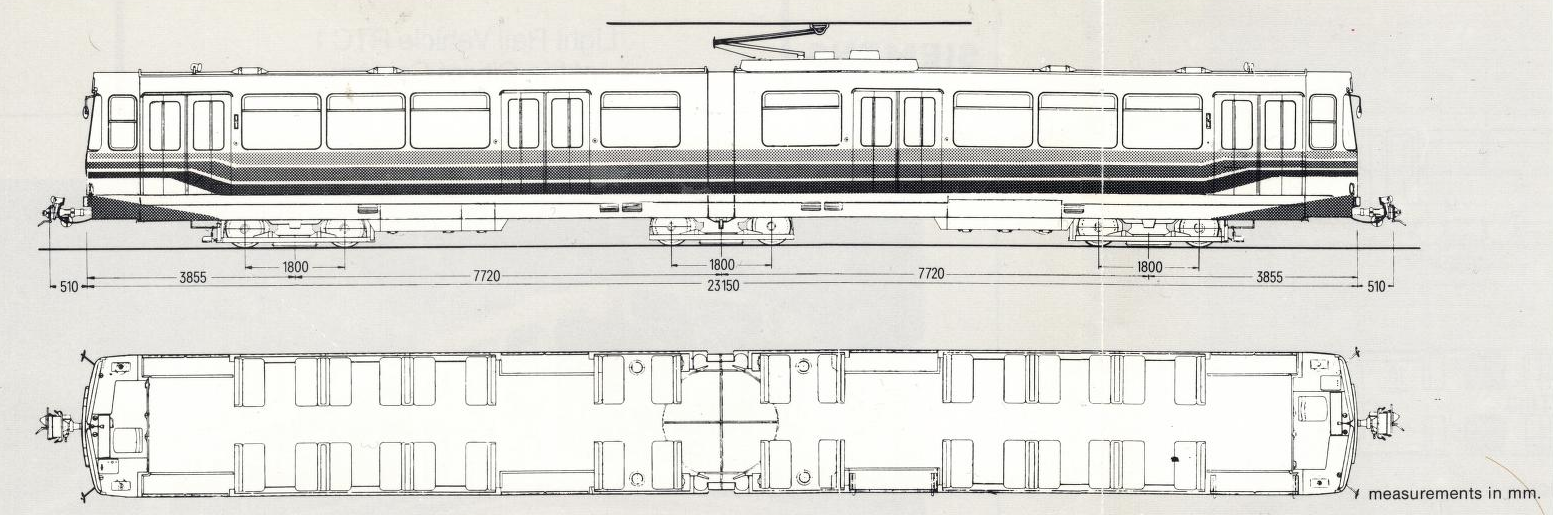

In [43]:
def posiciones_cargas(n_vagones, n_ejes, xc, d1, d2, d3):
    """
    Calcula las posiciones de los ejes del vagón.
    """
    posiciones = []
    for vagon in range(n_vagones):
        # Posición inicial de cada eje del vagón "n"
        if n_ejes == 1:
            X1 = d3 - ((vagon + 1) * d3 + vagon * d2) + d1 / 2
            posiciones.append([X1 + xc])
        elif n_ejes == 2:
            X1 = d3 - ((vagon + 1) * d3 + vagon * d2) + d1 / 2
            X2 = d3 - ((vagon + 1) * d3 + vagon * d2) - d1 / 2
            posiciones.append([X1 + xc])
        elif n_ejes == 3:
            X1 = d3 - ((vagon + 1) * d3 + vagon * d2) + d1 / 2
            X2 = d3 - ((vagon + 1) * d3 + vagon * d2) - d1 / 2
            X3 = d3 - ((vagon + 1) * d3 + (vagon + 1) * d2) + d1 / 2
            posiciones.append([X1 + xc, X2 + xc, X3 + xc])
        elif n_ejes == 4:
            X1 = d3 - ((vagon + 1) * d3 + vagon * d2) + d1 / 2
            X2 = d3 - ((vagon + 1) * d3 + vagon * d2) - d1 / 2
            X3 = d3 - ((vagon + 1) * d3 + (vagon + 1) * d2) + d1 / 2
            X4 = d3 - ((vagon + 1) * d3 + (vagon + 1) * d2) - d1 / 2
            posiciones.append([X1 + xc, X2 + xc, X3 + xc, X4 + xc])
        elif n_ejes == 6:
            X1 = d3 - ((vagon + 1) * d3 + vagon * d2) + d1 / 2
            X2 = d3 - ((vagon + 1) * d3 + vagon * d2) - d1 / 2
            X3 = d3 - ((vagon + 1) * d3 + (vagon + 1) * d2) + d1 / 2
            X4 = d3 - ((vagon + 1) * d3 + (vagon + 1) * d2) - d1 / 2
            X5 = d3 - ((vagon + 1) * d3 + vagon * d2) - 2 * d2 + d1 / 2
            X6 = d3 - ((vagon + 1) * d3 + vagon * d2) - 2 * d2 - d1 / 2
            posiciones.append([X1 + xc, X2 + xc, X3 + xc, X4 + xc, X5 + xc, X6 + xc])
        else:
            raise ValueError('Ingrese un número de ejes de 1 a 6')

    return posiciones

# Simulación de la carga móvil

def carga_movil(x_c, P, n_vagones, n_ejes, m1, m2, k1, k2,
                K_via, c1, c2, C_via, coord_nodos, conect,
                x0, d1, d2, d3, dof_malla):
    """
    Ensambla las matrices globales y el vector de fuerzas para la vía
    con todos los ejes de todos los vagones.
    """
    gdl_ejes = n_vagones * n_ejes * 2  # cada eje: 2 GDL (m1 y m2)
    tam = len(K_via) + gdl_ejes

    # Inicializar matrices
    F_global = np.zeros(tam, dtype=float)
    K_acoplada = np.zeros((tam, tam), dtype=float)
    C_acoplada = np.zeros((tam, tam), dtype=float)

    # Submatrices de un eje
    k_eje = np.array([[k1, -k1],
                      [-k1, k1 + k2]], dtype=float)
    c_eje = np.array([[c1, -c1],
                      [-c1, c1 + c2]], dtype=float)

    # Insertar los bloques de cada eje en la diagonal
    for e in range(n_vagones * n_ejes):
        idx = 2 * e
        K_acoplada[idx:idx + 2, idx:idx + 2] += k_eje
        C_acoplada[idx:idx + 2, idx:idx + 2] += c_eje
        # Peso de las masas
        F_global[idx] = -m1 * g
        F_global[idx + 1] = -m2 * g

    # Insertar matrices de la vía
    K_acoplada[gdl_ejes:, gdl_ejes:] = K_via
    C_acoplada[gdl_ejes:, gdl_ejes:] = C_via

    # Posiciones de todos los ejes en el tiempo t
    pos_cargas = [x for fila in posiciones_cargas(n_vagones, n_ejes, x_c, d1, d2, d3) for x in fila]

    # pos_cargas = posiciones_cargas(n_vagones, n_ejes, x_c, d1, d2, d3)

    # Recorrer cada eje y acoplar matrices y fuerzas
    for i, x_eje in enumerate(pos_cargas):
        for e, nodes in enumerate(conect):
            x1 = coord_nodos[nodes[0]][0]
            x2 = coord_nodos[nodes[1]][0]

            if min(x1, x2) <= x_eje <= max(x1, x2):
                L = abs(x2 - x1)
                xi = 2 * (x_eje - x1) / L - 1  # coordenada natural

                # Funciones de forma del elemento
                N = elemento_viga.mat_N_desp_giro(xi, L)
                Nv_w = np.array([0, N[1], N[2], 0, N[4], N[5]])
                f_elem = P * Nv_w

                # DOF globales del elemento (offset por gdl_ejes)
                dof_elem = np.array([
                    nodes[0] * dof_malla + 0,
                    nodes[0] * dof_malla + 1,
                    nodes[0] * dof_malla + 2,
                    nodes[1] * dof_malla + 0,
                    nodes[1] * dof_malla + 1,
                    nodes[1] * dof_malla + 2,
                ]) + gdl_ejes

                # Acoplar k2 y c2 entre eje y vía
                idx_node0 = nodes[0] * dof_malla + 1 + gdl_ejes
                idx_node1 = nodes[1] * dof_malla + 1 + gdl_ejes
                idx_eje = 2 * i + 1  # GDL vertical del eje i

                for M_acoplada, val in [(K_acoplada, k2), (C_acoplada, c2)]:
                    M_acoplada[idx_node0, idx_eje] += -val * N[1]
                    M_acoplada[idx_node1, idx_eje] += -val * N[4]
                    M_acoplada[idx_eje, idx_node0] += -val * N[1]
                    M_acoplada[idx_eje, idx_node1] += -val * N[4]
                    M_acoplada[idx_node0, idx_node0] += val * N[1]
                    M_acoplada[idx_node1, idx_node1] += val * N[4]


                # Agregar fuerzas equivalentes
                F_global[dof_elem] += f_elem
                break  # un solo elemento activo por eje

    return F_global, K_acoplada, C_acoplada


def masa_global(n_vagones: int, n_ejes: int, M_via, m1: float, m2: float):
    gdl_ejes = n_vagones * n_ejes * 2
    tam = len(M_via) + gdl_ejes
    M_global = np.zeros((tam, tam))

    for i in range(gdl_ejes):
        if i % 2 == 0:
            M_global[i, i] = m1
        else:
            M_global[i, i] = m2

    M_global[gdl_ejes:, gdl_ejes:] = M_via
    return M_global

Ecuación diferencial

In [44]:
def ec_dif_via(t: float, y: np.ndarray, m_inv, ndof, params):
    w = y[:ndof]
    dw = y[ndof:]

    # Calcular posición de la carga en función del tiempo
    if 'x_c' not in params.keys() or params['x_c'] is None:
        x_c = params["velocidad"] * t + params["x0"]
    else:
        x_c = np.interp(t, params["x_c"]["t"], params["x_c"]["x_c"])

    F, K, C = carga_movil(x_c, params["P"], params["n_vagones"], params["n_ejes"], params["m1"], params["m2"],
                          params["k1"], params["k2"], params["K_via"], params["c1"], params["c2"], params["C_via"],
                          params["coord_nodos"], params["conect"], params["x0"],
                          params["d1"], params["d2"], params["d3"], params["dof_malla"])
    # print(f'tiempo: {t}')

    # print(f'x_c: {x_c}')
    y_dot = np.hstack((dw, m_inv @ (F - C @ dw - K @ w)))

    if np.any(np.isnan(y_dot)) or np.any(np.isinf(y_dot)):
        print("Problema en t =", t)
        print("y =", y)
        raise ValueError("NaN/Inf detectado en ec_dif_via")
    return y_dot

Datos de entrada

C:\Users\joses\AppData\Local\Temp\ipykernel_80000\1600639847.py:64: RuntimeWarning:

divide by zero encountered in divide



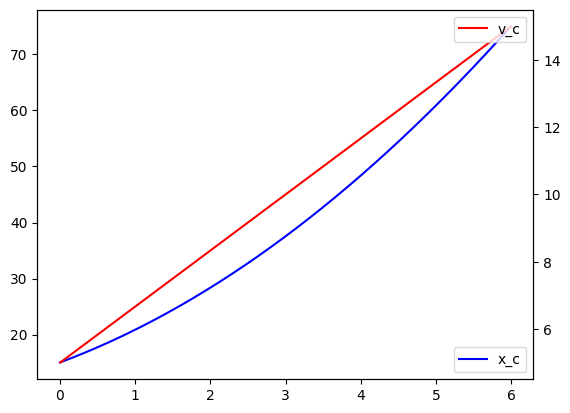

In [45]:
L = 80
# n_tot = int(1.5*L)
sep_dur = 0.5
n_tot = int(L / sep_dur) + 1
dof_malla = 3
g = 9.81  # aceleración de la gravedad
malla = MallaRiel(L, n_tot, dof_malla)
# Propiedades del perfil
a_r = np.ones(n_tot - 1) * 0.00315  # area de la sección transversal del riel [m2]
gamma_r = np.ones(n_tot - 1) * 7850  # masa específica del riel
m_r = 7850 * a_r  # masa por unidad de longitud
e_r = np.ones(n_tot - 1) * 2.1e11  # Módulo de elasticidad del riel
nu = np.ones(n_tot - 1) * 0.3  # Coeficiente de poisson del riel
i_r = np.ones(n_tot - 1) * 0.00003949  # momento de inercia riel
k_b = np.ones(n_tot - 1) * 5.3e7  # rigidez coeficiente de balasto
q_ = 0.0
prop_geometricas_mecanicas = PropGeomMecViga(m_r, a_r, e_r, gamma_r, i_r, k_b)
def q(x):
    return np.array([0, -q_, 0, 0, -q_, 0])

elemento_viga = ElementoViga(malla, prop_geometricas_mecanicas, q)

elementos_danados = {50: 0.25, 51: 0.25}  # Elijo que elementos y cuanto romperlos
# elementos_danados = {}
K, M, f = elemento_viga.ensamblar_matrices_globales(elementos_danados=elementos_danados)

gdl_restringidos = [0, 1, 2, (n_tot - 1) * dof_malla + 2, (n_tot - 1) * dof_malla + 1, (n_tot - 1) * dof_malla]

K_r, M_r, f_r = elemento_viga.aplicar_condiciones_dirichlet(K, M, f, gdl_restringidos)

# Parámetros de la simulación
t_simulacion = 6.0
delta_t = 0.005
t_eval = np.arange(0, t_simulacion, delta_t)

# Parámetros tren
m1 = 4050 # Lleno (265 pasajeros)
#m1 = 2500 # Vacío (0 pasajeros)
m2 = 500.0 # Masa del 1/4 de bogie
k1 = 7.5e10
k2 = 1e11
c1 = 0.01
c2 = 0.01
P = -(m1 + m2) * g
n_vagones = 1
n_ejes = 6
d1 = 1.8
d2 = 7.720
d3 = 0.0
a0 = 1e-2
a1 = 1e-3

x0 = 15.0
vx_0 = 5  # velocidad inicial en m/s
vx = 15  # velocidad max en m/s

# perfil lineal en velocidad
v_c = vx_0 + (vx - vx_0) * t_eval / t_simulacion
x_c_ = x0 + np.cumsum(v_c*delta_t)

x_c = {
    't': t_eval,
    'x_c': x_c_,
    'v_c': np.diff(x_c_, prepend=0)/np.diff(t_eval, prepend=0),      # dx/dt
}
ax = plt.axes()
ax.plot(x_c['t'], x_c['x_c'], color='b', label='x_c')
ax_ = ax.twinx()
ax_.plot(x_c['t'], x_c['v_c'], color='r', label='v_c')
ax.legend(loc='lower right')
ax_.legend(loc='upper right')
plt.show()

# Matrices FEM vía
M_via = M_r
K_via = K_r
C_r = a0 * M_r + a1 * K_r
C_via = C_r
M_global = masa_global(n_vagones, n_ejes, M_via, m1, m2)
m_inv = np.linalg.inv(M_global)
ndof = len(M_global)
y0 = np.zeros(2 * ndof)  # vector de condiciones iniciales

params = {
    "x_c": x_c,
    "velocidad": vx,  # m/s
    "P": P,
    "n_vagones": n_vagones,
    "n_ejes": n_ejes,
    "m1": m1, "m2": m2,
    "k1": k1, "k2": k2,
    "K_via": K_via,
    "c1": c1, "c2": c2,
    "C_via": C_via,
    "coord_nodos": malla.coord_nodos,
    "conect": malla.conect,
    "x0": x0,
    "d1": d1,
    "d2": d2,
    "d3": d3,
    "dof_malla": dof_malla
}

Gráfico de la malla

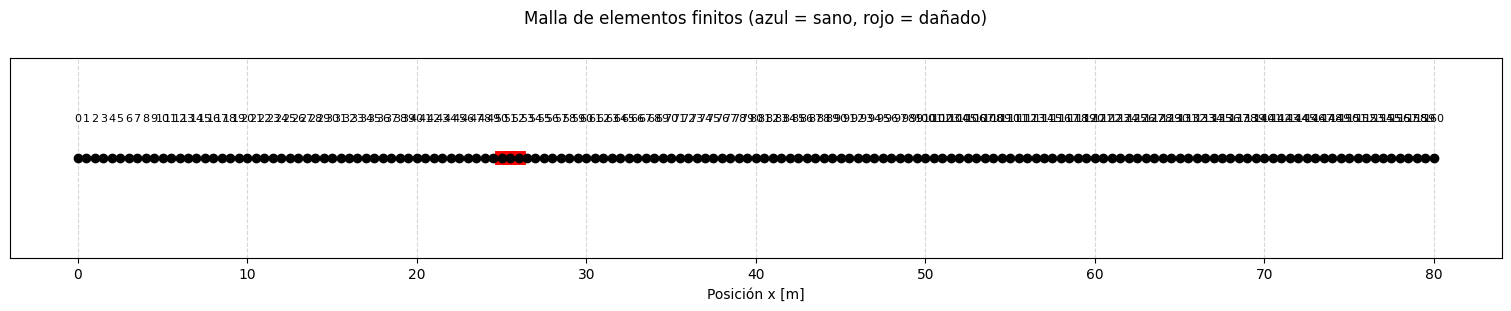

In [46]:
# Gráfico de la malla
fig, axs = plt.subplots(1, 1, figsize=(15, 3), constrained_layout=True)

# Malla con nodos y elementos
for e, (ni, nj) in enumerate(malla.conect):
    x = [malla.coord_nodos[ni, 0], malla.coord_nodos[nj, 0]]
    y = [0, 0]
    color = "red" if e in elementos_danados else "blue"
    size = 10 if e in elementos_danados else 2
    axs.plot(x, y, color=color, lw=size)

# dibujar nodos numerados
axs.scatter(malla.coord_nodos[:, 0], np.zeros(malla.n_tot), color="black", zorder=3)
for i, (x, y) in enumerate(malla.coord_nodos):
    axs.text(x, 0.02, str(i), ha="center", fontsize=8)

axs.set_title("Malla de elementos finitos (azul = sano, rojo = dañado)", pad=25)
axs.set_xlabel("Posición x [m]")
axs.set_yticks([])
axs.grid(True, linestyle="--", alpha=0.5)

Integración de la EDO

In [47]:
load_or_calculate = 'load'

filename_sol = 'sol.pkl'
if load_or_calculate == 'calculate':
    start_time = time.time()
    print(f'{t_simulacion=}')

    sol = solve_ivp(ec_dif_via, [0, t_simulacion], y0, method='Radau',
                    t_eval=t_eval, args=(m_inv, ndof, params),
                    vectorized=False,
                    dense_output=False,
                    events=None
                    )

    end_time = time.time()
    tiempo_transcurrido = end_time - start_time
    print(f'Tiempo transcurrido: {tiempo_transcurrido} seg = {tiempo_transcurrido / 60} minutos')
    with open(filename_sol, 'wb') as file:
        pickle.dump(sol, file)
elif load_or_calculate == 'load':
    with open(filename_sol, 'rb') as file:
        sol = pickle.load(file)
        print(f'Solución cargada desde archivo: {filename_sol}')

Solución cargada desde archivo: sol.pkl


In [48]:
t_eval

array([0.000e+00, 5.000e-03, 1.000e-02, ..., 5.985e+00, 5.990e+00,
       5.995e+00])

1200

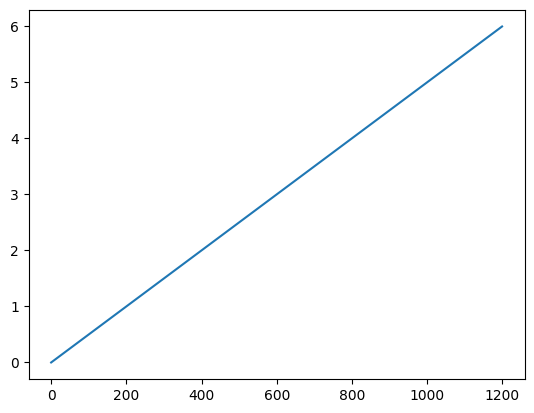

In [49]:
sol_t = sol.t
sol_y = sol.y.T
plt.plot(sol_t)
len(sol_y)

Post proceso

In [50]:
sol_y = np.array(sol_y).T
sol_t = np.array(sol_t)

def calc_a(i, t, sol_y):
    w = sol_y[0:ndof]
    dw = sol_y[ndof:2 * ndof]
    w_t = w[:, i]
    dw_t = dw[:, i]

    # Calcular posición de la carga en función del tiempo
    if 'x_c' not in params.keys() or params['x_c'] is None:
        x_c = params["velocidad"] * t + params["x0"]
    else:
        x_c = np.interp(t, params["x_c"]["t"], params["x_c"]["x_c"])

    F, K, C = carga_movil(
        x_c,
        params["P"],
        params["n_vagones"], params["n_ejes"],
        params["m1"], params["m2"],
        params["k1"], params["k2"],
        params["K_via"],
        params["c1"], params["c2"],
        params["C_via"],
        params["coord_nodos"],
        params["conect"],
        params["x0"], params["d1"], params["d2"], params["d3"],
        params["dof_malla"])
    return m_inv @ (F - C @ dw_t - K @ w_t)

w = sol_y[:ndof, :]
df_w = pd.DataFrame(w.T, index=sol_t, columns=[f"w{i}" for i in range(ndof)])

# velocidades
dw = sol_y[ndof: 2 * ndof, :]
df_dw = pd.DataFrame(dw.T, index=sol_t, columns=[f"dw{i}" for i in range(ndof)])

# aceleraciones
a = []
for i, t in enumerate(sol_t):
    try:
        ai = calc_a(i, t, sol_y)
    except IndexError:
        ai = np.nan
    a.append(ai)

a = np.array(a)
df_a = pd.DataFrame(a, index=sol_t, columns=[f"a{i}" for i in range(ndof)])

Gráficos: Desplazamiento de un nodo (o de alguna masa del tren) en función del tiempo

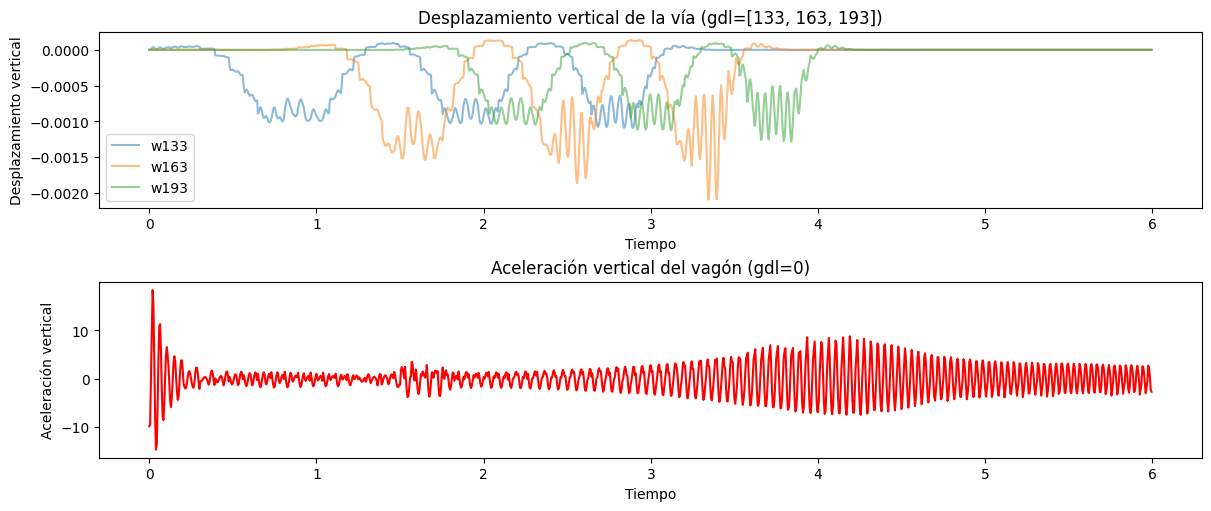

In [51]:
nodos_via = [40, 50, 60]
gdl_tren = 12

gdl = [gdl_tren + nodo_via * dof_malla + 1 for nodo_via in nodos_via]
gdl_acel = 0

desp_cols = df_w.iloc[:, gdl]
acel_cols = df_a.iloc[:, gdl_acel]

fig, axs = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)

desp_cols.plot(ax=axs[0], alpha=0.5)
axs[0].set_xlabel("Tiempo")
axs[0].set_ylabel("Desplazamiento vertical")
axs[0].set_title(f"Desplazamiento vertical de la vía (gdl={gdl})")

# Segundo subplot → aceleraciones
acel_cols.plot(ax=axs[1], color="red")
axs[1].set_xlabel("Tiempo")
axs[1].set_ylabel("Aceleración vertical")
axs[1].set_title(f"Aceleración vertical del vagón (gdl={gdl_acel})")

plt.show()

(0.0, 1.0)

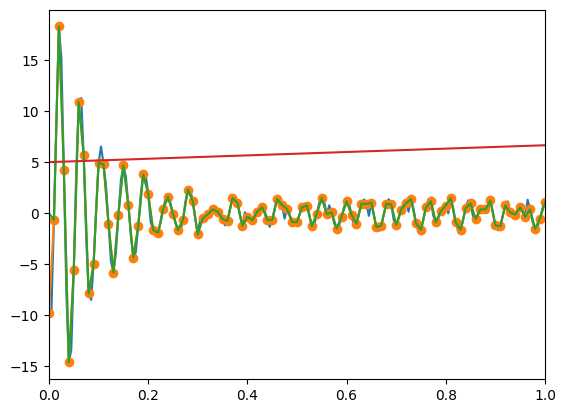

In [62]:
# Delta_t statistics
# print(pd.DataFrame(np.diff(acel_cols.index, 1)).describe())
fig, ax = plt.subplots()
ax.plot(acel_cols.index, acel_cols.values)
# ax.set_xlim([2.0, 3.5])

# subsampling at 100 sps
t_100sps = np.arange(0, acel_cols.index[-1], .01)
acel_cols_100sps = pd.Series(index=t_100sps,
                             data=np.interp(t_100sps, acel_cols.index, acel_cols.values))
ax.plot(t_100sps, acel_cols_100sps, marker='o')


# Transient ramp up
i_ini = 0
i_fin = 1
acel_cols_100sps.iloc[i_ini:i_fin] = acel_cols_100sps.iloc[i_ini:i_fin] * (1/(i_fin-i_ini))*np.arange(i_ini, i_fin)
ax.plot(t_100sps, acel_cols_100sps)


with open('acel_cols_100sps.pkl', 'wb') as file:
    pickle.dump(acel_cols_100sps, file)

acel_cols_100sps.to_csv('Accelerometer.csv')
with open('Accelerometer.csv', 'r') as file:
    lines = file.readlines()

lines[0] = "seconds_elapsed,z\n"

with open('Accelerometer.csv', 'w') as file:
    file.writelines(lines)

# simulate lat lon
t_1sps = np.arange(0, acel_cols.index[-1] + 1, 1.0)
data = {
    'seconds_elapsed': t_1sps,
    'speed': np.interp(t_1sps, x_c['t'][1:], x_c['v_c'][1:]),
    'latitude': np.interp(t_1sps, x_c['t'][1:], x_c['x_c'][1:]),
    'longitude': np.zeros(len(t_1sps))
}
location_1sps = pd.DataFrame(data=data)
location_1sps.to_csv('Location.csv')
ax.plot(data['seconds_elapsed'], data['speed'])

ax.set_xlim(0,1)

In [63]:
np.arange(i_ini, i_fin)

array([0])

In [64]:
acel_cols_100sps

0.00    -0.000000
0.01    -0.671672
0.02    18.334579
0.03     4.267749
0.04   -14.672878
          ...    
5.95     1.101583
5.96    -2.968535
5.97    -0.659307
5.98     2.148671
5.99    -2.251726
Length: 600, dtype: float64

Desplazamientos verticales en función de las coordenadas espaciales en un tiempo determinado


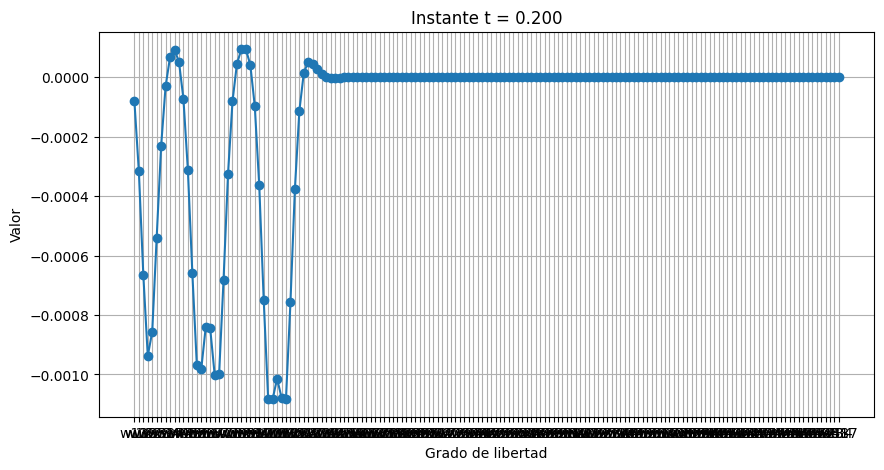

In [65]:
t_inst = 0.2

# Seleccionar la fila correspondiente al instante más cercano
fila = df_w.iloc[df_w.index.get_indexer([t_inst], method="nearest")]

# Seleccionar las columnas 16::3
subset = fila.iloc[:, gdl_tren + 1::dof_malla]

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(subset.columns, subset.values.flatten(), marker='o')
plt.xlabel("Grado de libertad")
plt.ylabel("Valor")
plt.title(f"Instante t = {fila.index[0]:.3f}")
plt.grid(True)
plt.show()

In [66]:
import plotly.graph_objects as go
from ipywidgets import IntSlider, VBox

tiempos = df_w.index.values
ymin = df_w.iloc[:, gdl_tren + 1::dof_malla].min().min()
ymax = df_w.iloc[:, gdl_tren + 1::dof_malla].max().max()

subset0 = df_w.iloc[0].iloc[gdl_tren + 1::dof_malla]
fig = go.FigureWidget(
    data=[go.Scatter(x=subset0.index, y=subset0.values, mode='markers+lines')],
    layout=go.Layout(title=f"Instante t = {tiempos[0]:.3f}", yaxis=dict(range=[ymin, ymax]))
)

slider = IntSlider(min=0, max=len(tiempos)-1, step=1, value=0)

def on_change(change):
    idx = change['new']
    subset = df_w.iloc[idx].iloc[gdl_tren + 1::dof_malla]
    with fig.batch_update():
        fig.data[0].x = subset.index
        fig.data[0].y = subset.values
        fig.layout.title = f"Instante t = {tiempos[idx]:.3f}"

slider.observe(on_change, names='value')
VBox([slider, fig])


    'data': [{'mode': 'markers+lines',
           …